In [ ]:
# Particle Filter implemendation from - https://www.youtube.com/watch?v=UDw_ez9OWOw&t=147s
# https://aleksandarhaber.com/clear-and-concise-particle-filter-tutorial-with-python-implementation-part-3-python-implementation-of-particle-filter-algorithm/?amp=1

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(23) # for reproducibility

In [315]:
"""
x_k = f(x_{k-1}, u_{k-1}, w_{k-1}) 

x_k = state vector at time step k
u_{k-1} = control input vector at time step k-1
w_{k-1} = process disturbance vector at time step k-1 (Process noise)

y_k = g(x_k, v_k) 
y_k = measurement vector at time step k
v_k = measurement noise vector at time step k

Generally, f and g are nonlinear functions

w_k ~ N(0, Q) - process noise is zero-mean Gaussian with covariance Q
v_k ~ N(0, R) - measurement noise is zero-mean Gaussian with covariance R

*** Main use for particle filters is when random vectora have non Gaussian probability distrubtions ***
- Different from all the kalman filters we have seen thus far (KF, EKF, UKF)

A stochastic process is a Markov if the probability of the state vector at time step k depends only on the state vector from the previous time step and its constants

The particle filters estimates the probability distribution of a stae using the measurements

Sum of weights are equal to one


"""


'\nx_k = f(x_{k-1}, u_{k-1}, w_{k-1}) \n\nx_k = state vector at time step k\nu_{k-1} = control input vector at time step k-1\nw_{k-1} = process disturbance vector at time step k-1 (Process noise)\n\ny_k = g(x_k, v_k) \ny_k = measurement vector at time step k\nv_k = measurement noise vector at time step k\n\nGenerally, f and g are nonlinear functions\n\nw_k ~ N(0, Q) - process noise is zero-mean Gaussian with covariance Q\nv_k ~ N(0, R) - measurement noise is zero-mean Gaussian with covariance R\n\n*** Main use for particle filters is when random vectora have non Gaussian probability distrubtions ***\n- Different from all the kalman filters we have seen thus far (KF, EKF, UKF)\n\nA stochastic process is a Markov if the probability of the state vector at time step k depends only on the state vector from the previous time step and its constants\n\nThe particle filters estimates the probability distribution of a stae using the measurements\n\nSum of weights are equal to one\n\n\n'

In [316]:
# Trajectory of the target
def trajectory(t):
    x = 5*t
    y = np.sin(t) * t**2
    return np.array([x, y])

def motion():
    dt = 0.1 
    A = np.array([ # [x, y, vx, vy]
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    Q = np.eye(4) * 10  # Process noise
    R = np.eye(2) * 1  # Measurement (x,y)
    return A, Q, R


def processNoise(N, Q):
    return np.random.multivariate_normal(np.zeros(4), Q, size=N)

def measurementNoise(N, R): 
    return np.random.multivariate_normal([0,0], R, size=N) # we use the measurement noise cov (R) to make the process noise vector (vk)

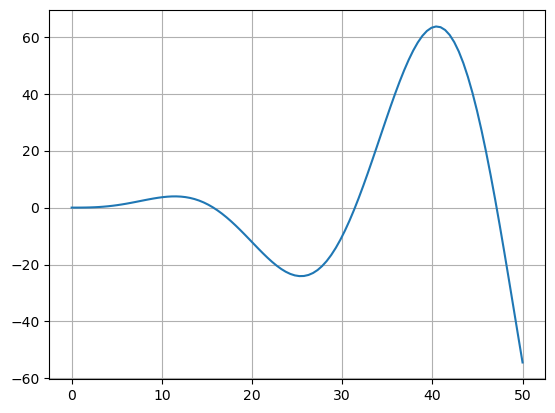

In [317]:
N = 2000 # number of particles
t = np.linspace(0, 10, 100) # time vector

state_estimate = [] # store
weights_history = []

trueState = trajectory(t).T 
plt.figure()
plt.grid()
plt.plot(trueState[:,0], trueState[:,1], label='True Trajectory')
plt.show()

A, Q, R = motion()
measurement = trueState + measurementNoise(len(t), R)

# init particles and weights
X0 = np.array([0.0, 0.0, 0.0, 0.0]) # [x, y, vx, vy]
particles = np.random.multivariate_normal(X0, Q, size=N)
weights = np.ones(N) / N

for i in range(len(t)):

    wk = processNoise(N, Q) # process noise for each particle
    particles = (A @ particles.T).T + wk

    probs = stats.multivariate_normal.pdf(particles[:, 0:2], mean=measurement[i], cov=R)    
    newWeights = probs * weights # update weights for all particles

    if np.sum(newWeights) == 0: # avoid division by zero
        newWeights = np.ones(N) / N
    weights = newWeights / np.sum(newWeights) # normalize weights
    
    temp = []
    for w in weights: # Iterate over elements, not len
        temp.append(w**2)
    Neff = 1 / np.sum(temp)

    if Neff < N / 3: # resample if effective number of particles is less than a third of total particles
        indices = np.random.choice(N, size=N, replace=True, p=weights)
        particles = particles[indices]
        weights = np.ones(N) / N

    state = np.average(particles, axis=0, weights=weights) 
    state_estimate.append(state)
state_estimate = np.array(state_estimate)

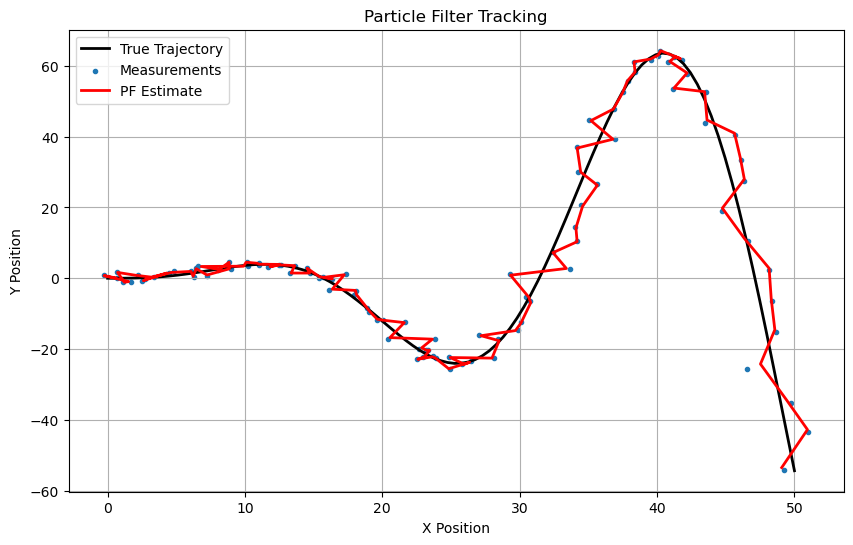

In [318]:
plt.figure(figsize=(10, 6))
plt.plot(trueState[:, 0], trueState[:, 1], label='True Trajectory', color='k', linewidth=2)
plt.scatter(measurement[:, 0], measurement[:, 1], marker='.', label='Measurements')
plt.plot(state_estimate[:, 0], state_estimate[:, 1], 'r-', label='PF Estimate', linewidth=2)
plt.title("Particle Filter Tracking")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()